# **1. Perkenalan Dataset**

Notebook ini merupakan adaptasi dari `Template_Eksperimen_MSML.ipynb` untuk proyek **Sistem Klasifikasi Performa Belajar Siswa** berbasis Open University Learning Analytics Dataset (OULAD).

Dataset OULAD berisi informasi demografi siswa, registrasi kelas, assessment, course, dan interaksi siswa pada Virtual Learning Environment (VLE). Pada proyek ini, dataset digunakan untuk membangun sistem klasifikasi risiko/performa belajar siswa sebagai dasar adaptive learning dan early warning system.

**Sumber dataset:**

Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2015). Open University Learning Analytics dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5KK69

**Target klasifikasi:**

Kolom `final_result` dari `studentInfo.csv` dipetakan menjadi target binary:

- `Pass` dan `Distinction` menjadi `Good`
- `Fail` dan `Withdrawn` menjadi `At_Risk`

Dengan pemetaan ini, model memprediksi apakah siswa berada pada kondisi performa baik atau berisiko membutuhkan intervensi pembelajaran.


Tahap pertama adalah memastikan dataset memenuhi kebutuhan submission dan relevan dengan masalah machine learning yang diselesaikan. Dataset OULAD dipilih karena memiliki data aktivitas LMS/VLE yang sesuai dengan konteks sistem pembelajaran digital.


# **2. Import Library**

Pada tahap ini, pustaka yang dibutuhkan untuk eksplorasi dataset dan preprocessing diimpor. Notebook ini hanya menggunakan pustaka umum seperti `pandas`, `numpy`, `matplotlib`, dan `seaborn`. Script preprocessing otomatis berada pada `automate_yesaya.py`.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in [start, *start.parents]:
        raw_dir = candidate / "dataset" / "open+university+learning+analytics+dataset"
        experiment_dir = candidate / "Eksperimen_SML_Yesaya"
        if raw_dir.exists() and experiment_dir.exists():
            return candidate
    raise FileNotFoundError("Project root tidak ditemukan. Jalankan notebook dari dalam folder project.")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "dataset" / "open+university+learning+analytics+dataset"
EXPERIMENT_DIR = PROJECT_ROOT / "Eksperimen_SML_Yesaya"
PREPROCESSING_DIR = EXPERIMENT_DIR / "preprocessing"
OUTPUT_DIR = EXPERIMENT_DIR / "open_UL_analysis_preprocessing"
OUTPUT_FILE = OUTPUT_DIR / "student_cleaned.csv"
METADATA_FILE = OUTPUT_DIR / "preprocessing_metadata.json"

PROJECT_ROOT, RAW_DIR, OUTPUT_FILE


(PosixPath('/home/yesaya/Documents/Pijak Program/proyek_akhir_membangun_sistem_machine_learning'),
 PosixPath('/home/yesaya/Documents/Pijak Program/proyek_akhir_membangun_sistem_machine_learning/dataset/open+university+learning+analytics+dataset'),
 PosixPath('/home/yesaya/Documents/Pijak Program/proyek_akhir_membangun_sistem_machine_learning/Eksperimen_SML_Yesaya/open_UL_analysis_preprocessing/student_cleaned.csv'))

# **3. Memuat Dataset**

Pada tahap ini, tabel-tabel utama OULAD dimuat. File `studentVle.csv` berukuran besar, sehingga pada tahap eksplorasi notebook hanya membaca sampel awal. Proses agregasi penuh terhadap `studentVle.csv` dilakukan oleh script otomatis `automate_yesaya.py` menggunakan chunk processing.


In [2]:
csv_files = {
    "courses": RAW_DIR / "courses.csv",
    "assessments": RAW_DIR / "assessments.csv",
    "student_info": RAW_DIR / "studentInfo.csv",
    "student_registration": RAW_DIR / "studentRegistration.csv",
    "student_assessment": RAW_DIR / "studentAssessment.csv",
    "vle": RAW_DIR / "vle.csv",
    "student_vle": RAW_DIR / "studentVle.csv",
}

for name, path in csv_files.items():
    if not path.exists():
        raise FileNotFoundError(f"File dataset tidak ditemukan: {path}")

courses = pd.read_csv(csv_files["courses"], na_values=["?"])
assessments = pd.read_csv(csv_files["assessments"], na_values=["?"])
student_info = pd.read_csv(csv_files["student_info"], na_values=["?"])
student_registration = pd.read_csv(csv_files["student_registration"], na_values=["?"])
student_assessment = pd.read_csv(csv_files["student_assessment"], na_values=["?"])
vle = pd.read_csv(csv_files["vle"], na_values=["?"])
student_vle_sample = pd.read_csv(csv_files["student_vle"], nrows=1000, na_values=["?"])

file_summary = pd.DataFrame(
    [
        {
            "table": name,
            "file_name": path.name,
            "size_mb": round(path.stat().st_size / (1024 * 1024), 2),
        }
        for name, path in csv_files.items()
    ]
)

shape_summary = pd.DataFrame(
    [
        {"table": "courses", "rows_loaded": len(courses), "columns": courses.shape[1]},
        {"table": "assessments", "rows_loaded": len(assessments), "columns": assessments.shape[1]},
        {"table": "student_info", "rows_loaded": len(student_info), "columns": student_info.shape[1]},
        {"table": "student_registration", "rows_loaded": len(student_registration), "columns": student_registration.shape[1]},
        {"table": "student_assessment", "rows_loaded": len(student_assessment), "columns": student_assessment.shape[1]},
        {"table": "vle", "rows_loaded": len(vle), "columns": vle.shape[1]},
        {"table": "student_vle_sample", "rows_loaded": len(student_vle_sample), "columns": student_vle_sample.shape[1]},
    ]
)

print("Ringkasan ukuran file:")
display(file_summary)
print("Ringkasan data yang dimuat:")
display(shape_summary)
student_info.head()


Ringkasan ukuran file:


,table,file_name,size_mb
0,courses,courses.csv,0.00
1,assessments,assessments.csv,0.01
2,student_info,studentInfo.csv,3.30
3,student_registration,studentRegistration.csv,1.08
4,student_assessment,studentAssessment.csv,5.43
5,vle,vle.csv,0.26
6,student_vle,studentVle.csv,432.81


Ringkasan data yang dimuat:


,table,rows_loaded,columns
0,courses,22,3
1,assessments,206,6
2,student_info,32593,12
3,student_registration,32593,5
4,student_assessment,173912,5
5,vle,6364,6
6,student_vle_sample,1000,6


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan EDA untuk memahami distribusi target, komposisi modul, missing value, dan karakter umum data. EDA ini menjadi dasar keputusan preprocessing dan feature engineering.


Distribusi final_result asli:


,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


Distribusi target binary:


,count
target_label,
At_Risk,17208
Good,15385


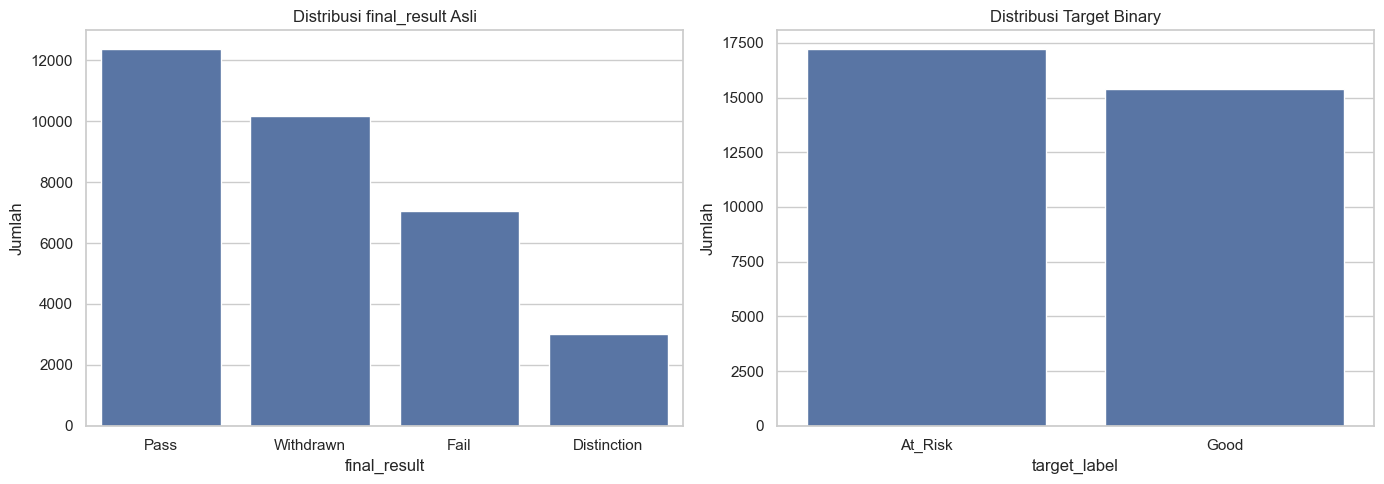

Missing value pada studentInfo.csv:


,missing_count,missing_percent
imd_band,1111,3.41


Distribusi target per module-presentation:


,code_module,code_presentation,target_label,count
14,CCC,2014J,At_Risk,1483
12,CCC,2014B,At_Risk,1273
36,FFF,2014J,At_Risk,1248
32,FFF,2013J,At_Risk,1188
6,BBB,2013J,At_Risk,1165
11,BBB,2014J,Good,1152
10,BBB,2014J,At_Risk,1140
37,FFF,2014J,Good,1117
18,DDD,2013J,At_Risk,1109
33,FFF,2013J,Good,1095


Statistik fitur numerik awal:


,num_of_prev_attempts,studied_credits
count,32593.000000,32593.000000
mean,0.163225,79.758691
std,0.479758,41.071900
min,0.000000,30.000000
25%,0.000000,60.000000
50%,0.000000,60.000000
75%,0.000000,120.000000
max,6.000000,655.000000


Contoh data aktivitas VLE:


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [3]:
target_map = {
    "Pass": "Good",
    "Distinction": "Good",
    "Fail": "At_Risk",
    "Withdrawn": "At_Risk",
}
student_info = student_info.copy()
student_info["target_label"] = student_info["final_result"].map(target_map)

print("Distribusi final_result asli:")
display(student_info["final_result"].value_counts().rename("count").to_frame())

print("Distribusi target binary:")
display(student_info["target_label"].value_counts().rename("count").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=student_info, x="final_result", ax=axes[0], order=student_info["final_result"].value_counts().index)
axes[0].set_title("Distribusi final_result Asli")
axes[0].set_xlabel("final_result")
axes[0].set_ylabel("Jumlah")

sns.countplot(data=student_info, x="target_label", ax=axes[1], order=["At_Risk", "Good"])
axes[1].set_title("Distribusi Target Binary")
axes[1].set_xlabel("target_label")
axes[1].set_ylabel("Jumlah")
plt.tight_layout()
plt.show()

missing_summary = (
    student_info.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_percent=lambda df: (df["missing_count"] / len(student_info) * 100).round(2))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)
print("Missing value pada studentInfo.csv:")
display(missing_summary)

module_summary = (
    student_info.groupby(["code_module", "code_presentation", "target_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Distribusi target per module-presentation:")
display(module_summary.head(15))

numeric_columns = ["num_of_prev_attempts", "studied_credits"]
print("Statistik fitur numerik awal:")
display(student_info[numeric_columns].describe())

print("Contoh data aktivitas VLE:")
display(student_vle_sample.head())


# **5. Data Preprocessing**

Tahap preprocessing dilakukan secara otomatis melalui `automate_yesaya.py`. Script tersebut menjalankan langkah berikut:

1. Membaca raw dataset OULAD.
2. Membuat target binary `Good` dan `At_Risk`.
3. Menggabungkan data siswa, course, registrasi, assessment, dan aktivitas VLE.
4. Mengagregasi assessment menjadi fitur seperti jumlah submission, skor rata-rata, weighted score, dan jumlah late submission.
5. Mengagregasi aktivitas VLE menjadi fitur seperti total klik, active days, klik sebelum course mulai, klik 30 hari pertama, dan klik 60 hari pertama.
6. Menangani missing value dengan kategori `Unknown` untuk kategorikal dan median untuk numerik.
7. Melakukan one-hot encoding fitur kategorikal.
8. Menyimpan dataset bersih ke `open_UL_analysis_preprocessing/student_cleaned.csv`.

Bagian ini menjalankan script otomatis dan memvalidasi output akhir.


In [4]:
if str(PREPROCESSING_DIR) not in sys.path:
    sys.path.insert(0, str(PREPROCESSING_DIR))

from automate_yesaya import main as run_preprocessing

run_preprocessing()

cleaned = pd.read_csv(OUTPUT_FILE)
metadata = json.loads(METADATA_FILE.read_text(encoding="utf-8"))

print("Metadata preprocessing:")
display({
    "rows": metadata["rows"],
    "columns": metadata["columns"],
    "feature_count": metadata["feature_count"],
    "target_column": metadata["target_column"],
    "target_distribution": metadata["target_distribution"],
})

print("Validasi dataset bersih:")
print(f"Shape: {cleaned.shape}")
print(f"Total missing value: {int(cleaned.isna().sum().sum())}")
print(f"Kolom target tersedia: {'target' in cleaned.columns}")
print(f"Kolom target_label tersedia: {'target_label' in cleaned.columns}")

display(cleaned["target_label"].value_counts().rename("count").to_frame())
display(cleaned.head())


Saved cleaned dataset: /home/yesaya/Documents/Pijak Program/proyek_akhir_membangun_sistem_machine_learning/Eksperimen_SML_Yesaya/open_UL_analysis_preprocessing/student_cleaned.csv
Saved metadata: /home/yesaya/Documents/Pijak Program/proyek_akhir_membangun_sistem_machine_learning/Eksperimen_SML_Yesaya/open_UL_analysis_preprocessing/preprocessing_metadata.json
Shape: 32593 rows x 69 columns
Target distribution:
target_label
At_Risk    17208
Good       15385
Name: count, dtype: int64
Metadata preprocessing:


{'rows': 32593,
 'columns': 69,
 'feature_count': 67,
 'target_column': 'target',
 'target_distribution': {'At_Risk': 17208, 'Good': 15385}}

Validasi dataset bersih:
Shape: (32593, 69)
Total missing value: 0
Kolom target tersedia: True
Kolom target_label tersedia: True


,count
target_label,
At_Risk,17208
Good,15385


,num_of_prev_attempts,studied_credits,module_presentation_length,date_registration,assessment_submitted_count,assessment_mean_score,assessment_min_score,assessment_max_score,assessment_late_count,assessment_banked_count,assessment_weighted_score,vle_total_clicks,vle_interaction_count,vle_first_click_day,vle_last_click_day,vle_clicks_before_start,vle_clicks_first_30_days,vle_clicks_first_60_days,vle_active_days,vle_avg_clicks_per_active_day,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013B,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_F,gender_M,region_East Anglian Region,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_A Level or Equivalent,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_0-10%,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_0-35,age_band_35-55,age_band_55<=,disability_N,disability_Y,target_label,target
0,0,240,268,-159.0,5.0,82.0,78.0,85.0,0.0,0.0,82.400000,934.0,196.0,-5.0,253.0,98.0,326.0,431.0,40.0,23.350000,1,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,Good,1
1,0,60,268,-53.0,5.0,66.4,60.0,70.0,2.0,0.0,65.400000,1435.0,430.0,-10.0,239.0,215.0,403.0,454.0,80.0,17.937500,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,Good,1
2,0,60,268,-92.0,7.0,76.0,60.0,92.0,1.0,0.0,72.033094,281.0,76.0,-10.0,12.0,102.0,179.0,179.0,12.0,23.416667,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,At_Risk,0
3,0,60,268,-52.0,5.0,76.0,71.0,88.0,0.0,0.0,76.300000,2158.0,663.0,-10.0,264.0,169.0,371.0,647.0,123.0,17.544715,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,Good,1
4,0,60,268,-176.0,5.0,54.4,30.0,75.0,5.0,0.0,55.000000,1034.0,352.0,-10.0,247.0,295.0,272.0,310.0,70.0,14.771429,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,Good,1
